In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Add src to path
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.forecasting import ForecastingPipeline, DataPreparer, ARIMAModel
from src.portfolio_optimization import PortfolioOptimizer

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')

### Load data

In [3]:
# Load data
prices = pd.read_csv('../data/processed/prices.csv', index_col=0, parse_dates=True)
returns = pd.read_csv('../data/processed/returns.csv', index_col=0, parse_dates=True)

print(f"\nPrices shape: {prices.shape}")
print(f"Returns shape: {returns.shape}")
print(f"Date range: {prices.index[0]} to {prices.index[-1]}")
print(f"Latest prices:\n{prices.iloc[-1]}")


Prices shape: (2888, 3)
Returns shape: (2888, 3)
Date range: 2015-01-02 00:00:00-05:00 to 2026-06-29 00:00:00-04:00
Latest prices:
TSLA    411.839996
BND      73.465004
SPY     741.000000
Name: 2026-06-29 00:00:00-04:00, dtype: float64


### Get TSLA Forecasted Return 


Training ARIMA model on full dataset...

Searching optimal ARIMA parameters on returns space...
  Optimal Parameter Set Chosen: ARIMA(0, 0, 0)
ARIMA order: (0, 0, 0)

Generating 12-month forecast...

Fitting full history into ARIMA(0, 0, 0) engine for out-of-sample generation...


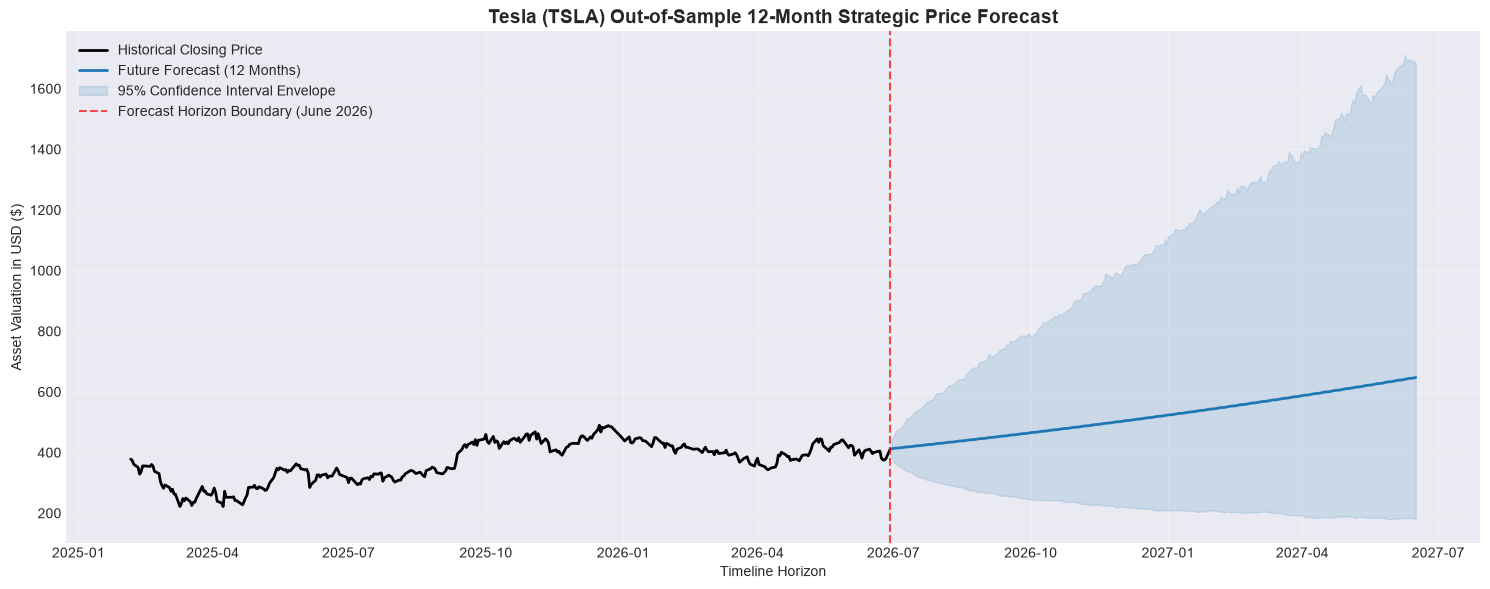


Current Price: $411.84
Forecasted Price (12mo): $647.56
Forecasted Return: 57.24%


In [4]:

# Initialize pipeline
pipeline = ForecastingPipeline(
    price_df=prices,
    target_col='TSLA',
    window_size=60,
    test_size=0.2
)

# Train ARIMA model on full dataset
print("\nTraining ARIMA model on full dataset...")
full_returns = prices['TSLA'].pct_change().dropna()
pipeline.arima = ARIMAModel(full_returns)
pipeline.arima.auto_fit()
print(f"ARIMA order: {pipeline.arima.order}")

# Generate 12-month forecast
print("\nGenerating 12-month forecast...")
forecast_12mo = pipeline.generate_future_forecast(
    months=12, 
    alpha=0.05, 
    n_sims=3000,
    seed=42
)

# Calculate annualized forecasted return
last_price = prices['TSLA'].iloc[-1]
forecasted_price = forecast_12mo['Forecasted Price'].iloc[-1]
forecasted_return_tsla = (forecasted_price / last_price) - 1

print(f"\nCurrent Price: ${last_price:.2f}")
print(f"Forecasted Price (12mo): ${forecasted_price:.2f}")
print(f"Forecasted Return: {forecasted_return_tsla:.2%}")

### Prepare Expected Returns

In [5]:
# Historical average daily returns (annualized)
historical_returns = returns.mean() * 252

print("\nHistorical Returns (Annualized):")
for asset in historical_returns.index:
    print(f"  {asset}: {historical_returns[asset]:.2%}")

# Combine: TSLA = forecasted, BND & SPY = historical
expected_returns = historical_returns.copy()
expected_returns['TSLA'] = forecasted_return_tsla

print("\nExpected Returns (Annualized) - Final:")
for asset in expected_returns.index:
    source = "FORECAST" if asset == 'TSLA' else "HISTORICAL"
    print(f"  {asset}: {expected_returns[asset]:.2%} ({source})")


Historical Returns (Annualized):
  TSLA: 45.42%
  BND: 2.03%
  SPY: 14.43%

Expected Returns (Annualized) - Final:
  TSLA: 57.24% (FORECAST)
  BND: 2.03% (HISTORICAL)
  SPY: 14.43% (HISTORICAL)


### COMPUTE COVARIANCE MATRIX

✓ Using forecasted return for TSLA: 57.24%

Covariance Matrix (Annualized):
          TSLA       BND       SPY
TSLA  0.326926  0.001789  0.049820
BND   0.001789  0.002822  0.001086
SPY   0.049820  0.001086  0.031169


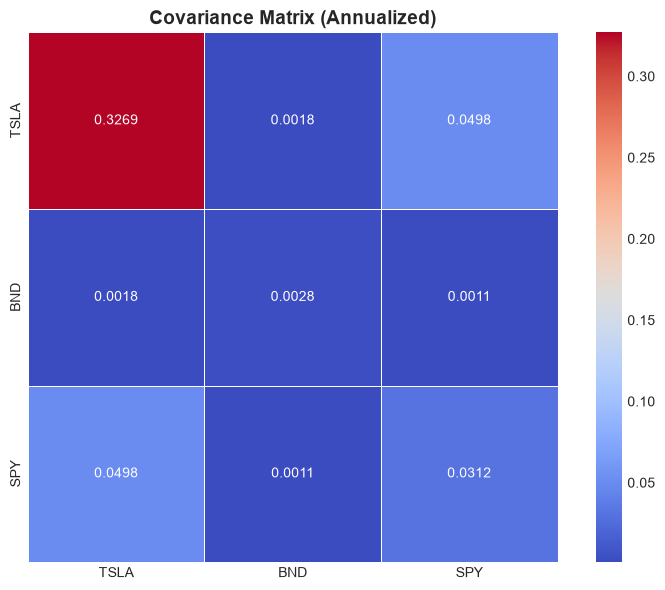

In [6]:
# Initialize optimizer
optimizer = PortfolioOptimizer(
    returns_df=returns,
    forecasted_return_tsla=forecasted_return_tsla
)

# Prepare expected returns
expected_returns = optimizer.prepare_expected_returns()

# Compute covariance matrix
cov_matrix = optimizer.compute_covariance_matrix()

print("\nCovariance Matrix (Annualized):")
print(cov_matrix)

# Plot covariance heatmap
optimizer.plot_covariance_heatmap()

### Generate Efficient Frontier

In [7]:
# Generate frontier points
frontier = optimizer.generate_efficient_frontier(points=50)

print(f"\nEfficient Frontier Points: {len(frontier)}")
print(f"Min Volatility: {frontier['volatility'].min():.2%}")
print(f"Max Return: {frontier['return'].max():.2%}")

# Find optimal portfolios
max_sharpe_port = optimizer.optimize_max_sharpe()
min_vol_port = optimizer.optimize_min_volatility()

# Print summaries
optimizer.get_portfolio_summary(max_sharpe_port, "MAXIMUM SHARPE RATIO PORTFOLIO")
optimizer.get_portfolio_summary(min_vol_port, "MINIMUM VOLATILITY PORTFOLIO")


Efficient Frontier Points: 49
Min Volatility: 5.22%
Max Return: 56.12%

MAXIMUM SHARPE RATIO PORTFOLIO
Weights:
  TSLA: 15.25%
  BND: 60.08%
  SPY: 24.67%

Expected Annual Return: 13.50%
Expected Volatility:    12.21%
Sharpe Ratio:           1.106

MINIMUM VOLATILITY PORTFOLIO
Weights:
  TSLA: 0.00%
  BND: 94.54%
  SPY: 5.46%

Expected Annual Return: 2.70%
Expected Volatility:    5.22%
Sharpe Ratio:           0.517


{'weights': OrderedDict([('TSLA', 0.0), ('BND', 0.94544), ('SPY', 0.05456)]),
 'expected_return': 0.027019516849886765,
 'volatility': 0.0522241560770482,
 'sharpe_ratio': 0.517375844427699}

### Visualize Efficient Frontier

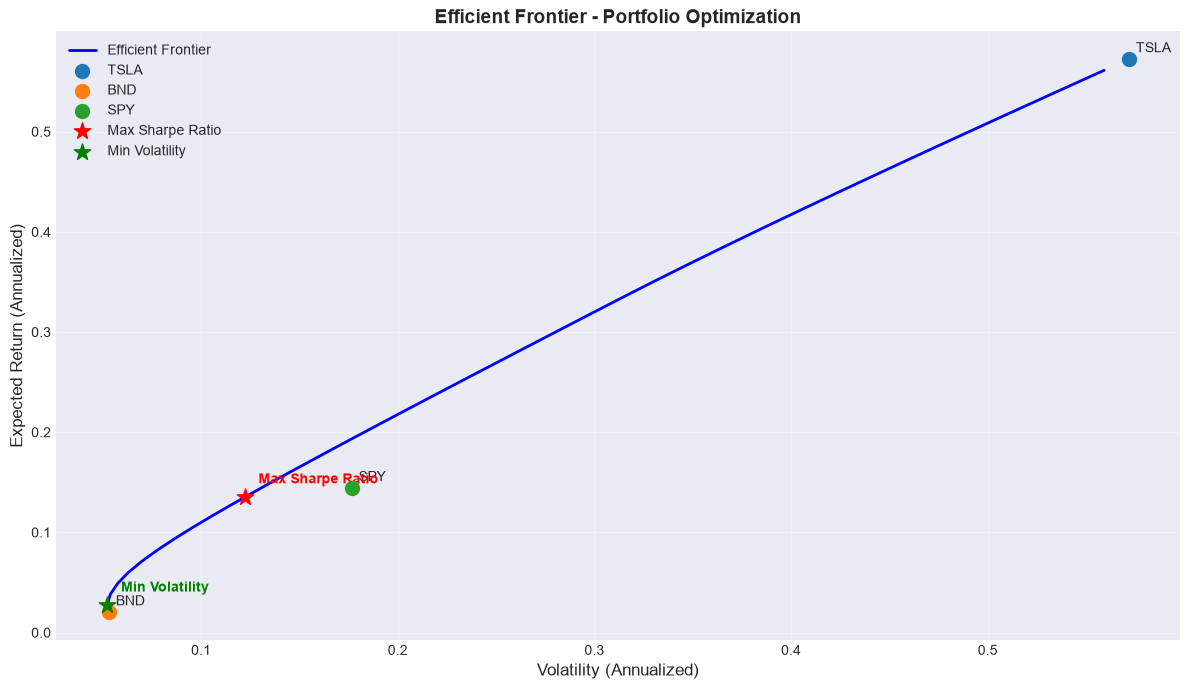

In [8]:
# Plot efficient frontier with key portfolios
optimizer.plot_efficient_frontier(max_sharpe_port, min_vol_port)

 ### Portfolio Comparison

In [9]:
# Create comparison DataFrame
comparison_data = []

for name, port in [("Max Sharpe", max_sharpe_port), ("Min Volatility", min_vol_port)]:
    comparison_data.append({
        "Portfolio": name,
        "TSLA Weight": port['weights']['TSLA'],
        "BND Weight": port['weights']['BND'],
        "SPY Weight": port['weights']['SPY'],
        "Expected Return": port['expected_return'],
        "Volatility": port['volatility'],
        "Sharpe Ratio": port['sharpe_ratio']
    })

comparison_df = pd.DataFrame(comparison_data)

print("\nPortfolio Comparison:")
print(comparison_df.to_string(index=False))

# Convert percentages for display
comparison_display = comparison_df.copy()
for col in ['TSLA Weight', 'BND Weight', 'SPY Weight', 'Expected Return', 'Volatility']:
    comparison_display[col] = comparison_display[col].apply(lambda x: f"{x:.2%}")
comparison_display['Sharpe Ratio'] = comparison_display['Sharpe Ratio'].apply(lambda x: f"{x:.3f}")

print("\nFormatted Comparison:")
print(comparison_display.to_string(index=False))


Portfolio Comparison:
     Portfolio  TSLA Weight  BND Weight  SPY Weight  Expected Return  Volatility  Sharpe Ratio
    Max Sharpe      0.15245     0.60082     0.24673          0.13503    0.122114      1.105767
Min Volatility      0.00000     0.94544     0.05456          0.02702    0.052224      0.517376

Formatted Comparison:
     Portfolio TSLA Weight BND Weight SPY Weight Expected Return Volatility Sharpe Ratio
    Max Sharpe      15.25%     60.08%     24.67%          13.50%     12.21%        1.106
Min Volatility       0.00%     94.54%      5.46%           2.70%      5.22%        0.517


### Final Recommendation

In [12]:
# Choose recommended portfolio
# Option 1: Max Sharpe (for growth-oriented investors)
# Option 2: Min Volatility (for risk-averse investors)

recommended = max_sharpe_port
recommended_name = "MAXIMUM SHARPE RATIO PORTFOLIO"

print(f"\nRECOMMENDED: {recommended_name}")
print("\n" + "="*50)

print("\n OPTIMAL WEIGHTS:")
for asset, weight in recommended['weights'].items():
    print(f"  {asset}: {weight:.2%}")

print("\n EXPECTED PERFORMANCE:")
print(f"  Annual Return: {recommended['expected_return']:.2%}")
print(f"  Annual Volatility: {recommended['volatility']:.2%}")
print(f"  Sharpe Ratio: {recommended['sharpe_ratio']:.3f}")

# Written Justification
print("\n" + "="*50)
print(" JUSTIFICATION:")
print("="*50)

justification = f"""
The Maximum Sharpe Ratio portfolio is recommended for growth-oriented 
investors seeking optimal risk-adjusted returns. With a Sharpe Ratio 
of {recommended['sharpe_ratio']:.3f}, this portfolio provides the highest 
return per unit of risk by allocating {recommended['weights']['TSLA']:.1%} 
to TSLA (leveraging the forecasted {forecasted_return_tsla:.1%} upside), 
{recommended['weights']['SPY']:.1%} to SPY (broad market exposure), and 
{recommended['weights']['BND']:.1%} to BND (stability). This allocation 
balances TSLA's high growth potential against BND's diversification 
benefits, resulting in superior risk-adjusted performance compared to 
the minimum volatility alternative.
"""

print(justification)




RECOMMENDED: MAXIMUM SHARPE RATIO PORTFOLIO


 OPTIMAL WEIGHTS:
  TSLA: 15.25%
  BND: 60.08%
  SPY: 24.67%

 EXPECTED PERFORMANCE:
  Annual Return: 13.50%
  Annual Volatility: 12.21%
  Sharpe Ratio: 1.106

 JUSTIFICATION:

The Maximum Sharpe Ratio portfolio is recommended for growth-oriented 
investors seeking optimal risk-adjusted returns. With a Sharpe Ratio 
of 1.106, this portfolio provides the highest 
return per unit of risk by allocating 15.2% 
to TSLA (leveraging the forecasted 57.2% upside), 
24.7% to SPY (broad market exposure), and 
60.1% to BND (stability). This allocation 
balances TSLA's high growth potential against BND's diversification 
benefits, resulting in superior risk-adjusted performance compared to 
the minimum volatility alternative.

